## Projeto FLY

### Indicadores

### Gráficos

### Carteira e Rebalanceamento

### Análise de Portfolio

## Alchemy


In [ ]:
# Jupyter cell: Initialize and optimize SQLite in FLY

# 1) Imports
from sqlalchemy import create_engine, text
from sqlalchemy.orm import sessionmaker

from infrastructure.config import Config

In [ ]:
# 2) Load application configuration
#    Adjust constructor as needed (e.g., passing path to config file or env vars)
config = Config()

In [ ]:
# 3) Create the SQLAlchemy engine with thread-safe and future settings
engine = create_engine(
    config.database.connection_string,
    connect_args={"check_same_thread": False},  # allow multi-thread access
    future=True,
)

In [ ]:
# 4) Execute SQLite PRAGMAs for performance & integrity
with engine.connect() as conn:  # type: ignore
    conn.execute(text("PRAGMA wal_checkpoint"))  # type: ignore

    # ou, se preferir garantir que todo o WAL seja aplicado e truncado:
    conn.execute(text("PRAGMA wal_checkpoint(FULL)"))  # type: ignore
    conn.execute(text("PRAGMA wal_checkpoint(RESTART)"))  # type: ignore
    conn.execute(text("PRAGMA wal_checkpoint(TRUNCATE)"))  # type: ignore
    conn.execute(text("PRAGMA optimize"))  # type: ignore # Run internal optimizations
    conn.execute(text("PRAGMA journal_mode=WAL"))  # type: ignore # Write-Ahead Logging
    conn.execute(text("PRAGMA synchronous=FULL"))  # type: ignore # Full disk sync for safety
    conn.execute(text("PRAGMA foreign_keys=ON"))  # type: ignore # Enforce FK constraints
    conn.execute(text("PRAGMA temp_store=MEMORY"))  # type: ignore # RAM for temp tables
    conn.execute(text("PRAGMA cache_size=-65536"))  # type: ignore # 64 MB cache

In [ ]:
# 5) Create a session factory for ORM transactions
Session = sessionmaker(  # type: ignore
    bind=engine,  # type: ignore
    autoflush=True,
    expire_on_commit=True,
)

In [ ]:
# 6) (Optional) Inspect existing tables
with Session() as session:  # type: ignore
    result = session.execute(text("SELECT name FROM sqlite_master WHERE type='table';"))  # type: ignore
    tables = [row[0] for row in result]
    print("⏺️ Tables in database:", tables)

## YFINANCE

In [ ]:
import yfinance as yf

tickers = ["LREN3.SA", "VALE3.SA"]

# Histórico diário
df = yf.download(tickers, start="1960-01-01", interval="1d",)


In [ ]:
df

### Preço atual e variação intraday

In [ ]:
info = yf.Tickers(" ".join(tickers))

for t in tickers:
    data = info.tickers[t].info
    print(
        t,
        "Preço:", data.get("regularMarketPrice"),
        "Variação:", data.get("regularMarketChange"),
        "Variação %:", data.get("regularMarketChangePercent"),
    )


### Dados fundamentais

In [ ]:
data = {}

for t in tickers:
    tk = yf.Ticker(t)
    info = tk.info
    data[t] = {
        "Nome": info.get("longName"),
        "Setor": info.get("sector"),
        "Indústria": info.get("industry"),
        "Valor de Mercado": info.get("marketCap"),
        "P/L": info.get("trailingPE"),
        "Lucro por Ação (EPS)": info.get("trailingEps"),
        "Dividend Yield": info.get("dividendYield"),
        "Beta": info.get("beta"),
        "Moeda": info.get("currency"),
    }

import pandas as pd
df = pd.DataFrame(data).T
df


In [ ]:

t = yf.Ticker("VAle3.SA")

# Retorna todos os campos de fundamentos
info = t.info

# Converter para DataFrame para melhor leitura
df = pd.DataFrame(info.items(), columns=["Campo", "Valor"])
df

### Dados financeiros estruturados

In [ ]:
import yfinance as yf

tickers = ["LREN3.SA"]

for t in tickers:
    tk = yf.Ticker(t)

    print(f"\n--- {t} ---")

    # Demonstrativos de resultado (anual e trimestral)
    print("Income Statement (anual):")
    print(tk.financials)

    print("\nIncome Statement (trimestral):")
    print(tk.quarterly_financials)

    # Balanço patrimonial
    print("\nBalance Sheet (anual):")
    print(tk.balance_sheet)

    print("\nBalance Sheet (trimestral):")
    print(tk.quarterly_balance_sheet)

    # Fluxo de caixa
    print("\nCashflow (anual):")
    print(tk.cashflow)

    print("\nCashflow (trimestral):")
    print(tk.quarterly_cashflow)


In [ ]:
tk.eps_revisions

## BCB Series

### BCB Series Download

In [ ]:
import requests
from bs4 import BeautifulSoup
import time
import csv
import os
import re

In [ ]:
# --- FILE NAMES
csv_file_name = 'bcb_series_completas2.csv'
csv_headers = [
        'Codigo', 'Nome_Completo', 'Unidade', 'Periodicidade', 'Data_Inicio', 'Ultimo_Valor', 'Fonte'
    ]

# --- URLs de Ação (Sequência Mínima) ---
BASE_URL = "https://www3.bcb.gov.br/sgspub"
SEARCH_POST_URL = f"{BASE_URL}/localizarseries/localizarSeries.paint?method=localizarSeriesPorPesquisaAvancada"
PAGINATION_URL = f"{BASE_URL}/localizarseries/localizarSeries.do?method=getPagina"

METADATA_URL = f'{BASE_URL}/localizarseries/localizarSeries.do?method=recuperarMetadadosPorDocn'
METADADOS_BASICOS_URL = f'{BASE_URL}/JSP/consultarmetadados/cmiDadosBasicos.jsp'
METADADOS_COMPLETOS_URL = f'{BASE_URL}/JSP/consultarmetadados/cmiMetadados.jsp'

# --- HEADERS ---
HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36',
    'Content-Type': 'application/x-www-form-urlencoded',
}

# --- PAYLOADS ---
INITIAL_PAYLOAD = {
    'codigos': '', 'periodicidade': '0', 'fonte': '0', 'unidadePadrao': '0',
    'filtro': '0', 'chkClassificacao': 'on', 'txtPesquisa': '', 'ordem1': '0',
    'sentido1': '0', 'ordem2': '0', 'sentido2': '0', 'ordem3': '0',
    'sentido3': '0', 'hdCodigos': '', 'hdGrupos': '', 'hdTipoPesquisa': '9',
    'hdTipoOrdenacao': '0', 'hdPeriodicidade': 'Todas', 'hdFonte': 'Todas',
    'hdUnidadePadrao': 'Todas', 'hdFiltro': ''
}
BASE_PAYLOAD_PAGINATION = {
    'periodicidade': '0', 'codigo': '', 'fonte': '341', 'texto': '',
    'hdFiltro': '', 'hdOidGrupoSelecionado': '', 'hdSeqGrupoSelecionado': '',
    'hdNomeGrupoSelecionado': '', 'hdTipoPesquisa': '9', 'hdTipoOrdenacao': '0',
    'hdPeriodicidade': 'Todas', 'hdSeriesMarcadas': '', 'hdMarcarTodos': '',
    'hdFonte': '', 'hdOidSerieMetadados': '', 'hdNumeracao': '',
    'hdOidSeriesLocalizadas': '',
    'linkRetorno': '/sgspub/consultarvalores/telaCvsSelecionarSeries.paint',
    'linkCriarFiltros': '/sgspub/manterfiltros/telaMfsCriarFiltro.paint'
}
METADATA_PAYLOAD_BASE = { 
    # ... (Campos do seu payload de metadados aqui) ...
    'hdOidSerieMetadados': '', # OBRIGATÓRIO: Código da Série
    'linkRetorno': '/sgspub/consultarvalores/telaCvsSelecionarSeries.paint',
    'linkCriarFiltros': '/sgspub/manterfiltros/telaMfsCriarFiltro.paint'
}
HEADERS_TO_IGNORE = ["Sumário Metodológico", "Formatos de Divulgação", "Summary Methodology", "Dissemination Formats", ]


In [ ]:
def clean_cell(text):
    if not isinstance(text, str):
        return text

    text = text.replace('\x96', '–').replace('\x93', '"').replace('\x94', '"')
    text = text.replace('\xa0', ' ') # Remove Non-breaking space
    text = text.replace('*', '') # <--- REMOVE O ASTERISCO DE QUALQUER CHAVE OU VALOR

    # 2. Regex: Substitui qualquer sequência de whitespace por um único espaço
    text= re.sub(r'\s+', ' ', text).strip()

    return text


In [ ]:
def save_to_csv(data_list, csv_file_name):
    if not data_list:
        print("Nenhum dado para salvar em CSV.")
        return

    csv_headers = []

    # 2. Set para garantir a unicidade e rapidez na checagem
    seen_fields = set()

    # Itera sobre cada dicionário de metadados
    for series_dict in data_list:
        # Itera sobre as chaves do dicionário (a ordem de iteração é importante)
        for field in series_dict.keys():
            if field not in seen_fields:
                # Adiciona à lista de cabeçalhos e ao set de controle
                csv_headers.append(field)
                seen_fields.add(field)

    try:
        with open(csv_file_name, 'w', newline='', encoding='utf-8') as f:
            writer = csv.DictWriter(f, fieldnames=csv_headers, quoting=csv.QUOTE_ALL, restval='')

            writer.writeheader()
            writer.writerows(data_list)

        print(f"Total de {len(data_list)} séries salvas em '{csv_file_name}'.")

    except Exception as e:
        print(f"ERRO ao salvar o arquivo CSV: {e}")

In [ ]:
def parse_page_data(html_content):
    """Extrai os dados da tabela HTML, retornando uma lista de dicionários."""
    soup = BeautifulSoup(html_content, 'html.parser')

    table = soup.find('table', id='tabelaSeries')
    if not table:
        return []

    series_data = []

    # Busca todas as linhas (<tr>) diretamente na <table>.
    all_rows = table.find_all('tr')

    for row in all_rows:
        cells = row.find_all('td', recursive=False)

        # Ignora linhas de cabeçalho e linhas incompletas.
        if len(cells) < 10:
            continue

        # Mapeamento dos dados
        data = {
            'Codigo': clean_cell(cells[1].text),
            'Nome_Completo': clean_cell(cells[2].text),
            'Unidade': clean_cell(cells[3].text),
            'Periodicidade': clean_cell(cells[4].text),
            'Data_Inicio': clean_cell(cells[5].text),
            'Ultimo_Valor': clean_cell(cells[6].text),
            'Fonte': clean_cell(cells[7].text),
        }
        series_data.append(data)

    return series_data

In [ ]:
def fetch_series(series, soup_basico, metadata_completo):
    metadata = {}
    metadata_basico = soup_basico.find_all('table')
    for t, table in enumerate(metadata_basico):
        rows = table.find_all('tr')
        for r, row in enumerate(rows):
            # Buscar células de dados (<td>)
            cells = row.find_all('td')
            # Assume a estrutura de 4 colunas (Rótulo, Valor, Rótulo, Valor)
            for i in range(0, len(cells), 2):
                if i + 1 < len(cells):
                    label = clean_cell(cells[i].text)
                    value = clean_cell(cells[i+1].text)
                    if label:
                        metadata[label] = value

    last_cell = None
    for t, table in enumerate(metadata_completo):
        rows = table.find_all('tr')
        for r, row in enumerate(rows):
            cells = row.find_all('td')
            cell_count = len(cells)
            if cell_count > 2:
                continue
            elif cell_count == 2:
                # Condição: Rótulo e Valor na mesma linha (Estrutura 2-col)
                # O bloco anterior de iteração foi removido
                label = clean_cell(cells[0].text)
                value = clean_cell(cells[1].text)

                if label and label not in HEADERS_TO_IGNORE:
                    metadata[label] = value

                # Zera o last_cell, pois um par K:V completo foi encontrado
                last_cell = None 

            elif cell_count == 1:
                # Condição: Máquina de Estados para conteúdo multi-linha (Estrutura 1-col)
                content = clean_cell(cells[0].text)

                # 1. Se existe uma chave pendente (last_cell):
                if last_cell:
                    # O 'content' atual é o VALOR para a chave pendente.
                    # Se o conteúdo estiver vazio, armazena vazio. Se tiver texto longo, armazena o texto limpo.
                    metadata[last_cell] = content
                    # Zera o estado após encontrar o valor
                    last_cell = None 

                # 2. Se NÃO existe chave pendente e o 'content' é um rótulo válido:
                elif content and content not in HEADERS_TO_IGNORE:
                    # O 'content' é um novo rótulo (chave) que espera um valor na próxima linha
                    last_cell = content
    series.update(metadata)

    return series


In [ ]:
def scrape_all_series(page_num=1):
    """Executa o scraping completo e retorna a lista de dicionários de séries."""
    all_data = []
    session = requests.Session()
    max_retries = 3

    # --- 1. ESTABELECIMENTO DE SESSÃO ---
    response_session = session.get(BASE_URL)
    response_initial = session.post(SEARCH_POST_URL, data=INITIAL_PAYLOAD, headers=HEADERS, timeout=30)

    # --- 2. LOOP DE PAGINAÇÃO ---
    page_num = page_num or 1
    previous_content_hash = hash(response_initial.text)
    previous_content_hash = hash(response_session.text)

    while True:
        current_payload = BASE_PAYLOAD_PAGINATION.copy()
        current_payload['hdNumPagina'] = str(page_num)

        retries = 0
        current_html = ""

        # Tenta o request de paginação
        while retries < max_retries:
            try:
                response_page = session.post(PAGINATION_URL, data=current_payload, headers=HEADERS, timeout=10)
                response_page.raise_for_status() 
                current_html = response_page.text
                break
            except requests.exceptions.RequestException:
                retries += 1
                time.sleep(3)

        if retries == max_retries:
            print(f"Falha na página {page_num}. Abortando.")
            break

        # Verifica se o conteúdo é o mesmo da página anterior (indicador de fim)
        current_content_hash = hash(current_html.replace('\r\n', ''))
        if current_content_hash == previous_content_hash:
            print(f"Conteúdo da página {page_num} idêntico. Fim da paginação.")
            break

        previous_content_hash = current_content_hash

        data_page = parse_page_data(current_html)

        if not data_page:
            print(f"Página {page_num} não retornou linhas. Encerrando.")
            break

        series_data = []
        for s, series in enumerate(data_page):
            payload = METADATA_PAYLOAD_BASE.copy()
            codigo = series['Codigo'] # Inserindo o código dinamicamente
            fonte = series['Fonte']
            nome = series['Nome_Completo']
            payload['hdOidSerieMetadados'] = codigo

            print(f"Página {page_num}-{(len(all_data)+s)} {codigo}-{fonte}-{nome}")
            session.post(METADATA_URL, data=payload, headers=HEADERS, timeout=10)
            response_basico = session.get(METADADOS_BASICOS_URL, headers=HEADERS, timeout=10)
            soup_basico = BeautifulSoup(response_basico.text, 'html.parser')

            response_completo = session.get(METADADOS_COMPLETOS_URL, headers=HEADERS, timeout=10)
            soup_completo = BeautifulSoup(response_completo.text, 'html.parser')
            metadata_completo = soup_completo.find_all('table')

            updated_series = fetch_series(series, soup_basico, metadata_completo)
            series_data.append(updated_series) # Usa append() para adicionar o dicionário)

        all_data.extend(series_data)
        if all_data is not None:
            save_to_csv(all_data, csv_file_name)
            print(f"Página {page_num} capturada. Total geral: {len(all_data)}")
        else:
            print("Processo de scraping falhou. Verifique as mensagens de erro acima.")

        page_num += 1
        # time.sleep(0.3)

    print("\nColeta finalizada.")
    return all_data

In [ ]:
# 1. Executa o scraping e armazena o resultado
bcb_series = scrape_all_series()

# 2. Salva a lista em CSV
if bcb_series is not None:
    save_to_csv(bcb_series, csv_file_name)
else:
    print("Processo de scraping falhou. Verifique as mensagens de erro acima.")

In [ ]:
df = pd.read_csv(r"D:\Fausto Stangler\Documentos\Python\FLY\bcb_series_completas.csv", dtype=str, )


In [ ]:
fontes = df['Fonte'].unique()
fontes

In [ ]:
dfs = {}
for fonte in fontes:
    mask = df['Fonte'] == fonte
    dfs[fonte] = df[mask][['Codigo', 'Short name', ]].drop_duplicates()

In [ ]:
df['Fonte'] == 'FGV'

In [ ]:
mask = df['Fonte'] == 'FGV'
df[mask]

### BCB Series CSV

In [53]:
import pandas as pd
import re
import os


In [7]:
csv_file = r"D:\Fausto Stangler\Documentos\Python\FLY\bcb_series_completas.csv"
df = pd.read_csv(csv_file, dtype=str, low_memory=False)
df['Codigo'] = df['Codigo'].astype('Int64')
cols = ['Codigo', 'Fonte', 'Short name', 'Full name', 'Periodicity', 'Ultimo_Valor', 'Series type', 'Subject chain']
df = df[cols]
df

,Codigo,Fonte,Short name,Full name,Periodicity,Ultimo_Valor,Series type,Subject chain
0,1,Sisbacen PTAX800,Commercial exchange rate,Exchange rate - Free - United States dollar (s...,Daily,23/04/2025,COMMON,- External sector statistics - Exchange rates ...
1,3,Sisbacen PTAX800,Turism exchange rate,Exchange rate - Floating - United States dolla...,Daily,29/01/1999,COMMON,- External sector statistics - Exchange rates ...
2,4,BM&FBOVESPA,BM&F Gold - gramme,BM&F Gold - gramme,Daily,30/09/2019,COMMON,- Capital and financial markets - Enabled series
3,5,LBMA,Gold London - troy ounce,Gold London - troy ounce,Daily,30/09/2019,COMMON,- Capital and financial markets - Enabled series
4,7,BM&FBOVESPA,Bovespa index,Bovespa index,Daily,30/09/2019,COMMON,- Capital and financial markets - Enabled series
...,...,...,...,...,...,...,...,...
19271,29626,CIP,Credit Portability - Other assets financing: R...,Credit Portability - Other assets financing: R...,Monthly,jul/2025,COMMON,- Credit statistics - Credit Portability
19272,29627,CIP,Credit Portability - Real Estate Credit (SFH):...,Credit Portability - Real Estate Credit (SFH):...,Monthly,jul/2025,COMMON,- Credit statistics - Credit Portability
19273,29628,CIP,Credit Portability - Real Estate Credit (SFI):...,Credit Portability - Real Estate Credit (SFI):...,Monthly,jul/2025,COMMON,- Credit statistics - Credit Portability
19274,29629,CIP,Credit Portability - Real Estate Credit (Enter...,Credit Portability - Real Estate Credit (Enter...,Monthly,jul/2025,COMMON,- Credit statistics - Credit Portability


In [67]:
def parse_date(x):
    x = str(x).strip().lower()
    if re.match(r'^\d{4}$', x):  # ano puro
        return pd.Timestamp(f"{x}-12-31")
    if re.match(r'^[a-z]{3}/\d{4}$', x):  # formato tipo jan/2024
        return pd.to_datetime(x, format='%b/%Y', errors='coerce')
    if re.match(r'^\d{2}/\d{2}/\d{4}$', x):  # formato tipo 31/12/2024
        return pd.to_datetime(x, format='%d/%m/%Y', errors='coerce')
    if "quar" in x or "tri" in x:  # trimestre (ex: '1º Quar. 2024')
        ano = re.findall(r'\d{4}', x)
        mes = re.findall(r'1º|2º|3º|4º', x)
        if ano and mes:
            trimestre = {"1º": "03", "2º": "06", "3º": "09", "4º": "12"}[mes[0]]
            return pd.Timestamp(f"{ano[0]}-{trimestre}-30")
    return pd.NaT

df["Ultimo_Valor_dt"] = df["Ultimo_Valor"].apply(parse_date)
df = df[df["Ultimo_Valor_dt"] >= pd.Timestamp("2024-01-01")]
df

,Codigo,Fonte,Short name,Full name,Periodicity,Ultimo_Valor,Series type,Subject chain,Ultimo_Valor_dt
0,1,Sisbacen PTAX800,Commercial exchange rate,Exchange rate - Free - United States dollar (s...,Daily,23/04/2025,COMMON,- External sector statistics - Exchange rates ...,2025-04-23
8,11,BCB-Demab,Selic,Interest rate - Selic,Daily,03/10/2025,COMMON,- Capital and financial markets - Financial ma...,2025-10-03
9,12,Cetip,CDI,Interest rate - CDI,Daily,02/10/2025,COMMON,- Capital and financial markets - Financial ma...,2025-10-02
11,14,Sisbacen PESP300,Average preset time deposits rate (CDB/RDB) - ...,Average preset time deposits rate (CDB/RDB) - ...,Daily,29/01/2024,DERIVATIVE,- Capital and financial markets - Time deposit...,2024-01-29
12,15,Sisbacen PESP300,Preset time deposits balance (CDB/RDB) - Total,Preset time deposits balance (CDB/RDB) - Total,Daily,31/01/2024,DERIVATIVE,- Capital and financial markets - Time deposit...,2024-01-31
...,...,...,...,...,...,...,...,...,...
19271,29626,CIP,Credit Portability - Other assets financing: R...,Credit Portability - Other assets financing: R...,Monthly,jul/2025,COMMON,- Credit statistics - Credit Portability,2025-07-01
19272,29627,CIP,Credit Portability - Real Estate Credit (SFH):...,Credit Portability - Real Estate Credit (SFH):...,Monthly,jul/2025,COMMON,- Credit statistics - Credit Portability,2025-07-01
19273,29628,CIP,Credit Portability - Real Estate Credit (SFI):...,Credit Portability - Real Estate Credit (SFI):...,Monthly,jul/2025,COMMON,- Credit statistics - Credit Portability,2025-07-01
19274,29629,CIP,Credit Portability - Real Estate Credit (Enter...,Credit Portability - Real Estate Credit (Enter...,Monthly,jul/2025,COMMON,- Credit statistics - Credit Portability,2025-07-01


In [71]:
subject_chain = df['Subject chain'][df['Subject chain'].notna()].unique()

processed_chain = [
    [segment.strip() for segment in item.split('-') if segment.strip()]
    for item in subject_chain
]
processed_chain = pd.DataFrame(processed_chain)



In [72]:
subjects = []
for idx, row in processed_chain.iterrows():
    chain = []
    for col in processed_chain.columns:
        val = row[col]
        if pd.isna(val):
            break
        chain.append(val)
    subjects.append(chain)
len(subjects)


536

In [73]:
masks = {}
for chain in subjects:
    pattern = '.*'.join(map(re.escape, chain))
    index = "-".join(chain)
    mask = df['Subject chain'].str.contains(pattern, case=False, na=False)
    subset = df[mask]
    masks[index] = subset



In [74]:
folder = "bcb_series"
os.makedirs(folder, exist_ok=True)

for index, subset in masks.items():
    safe_name = re.sub(r'[\\/*?:"<>|]', "_", index)
    path = os.path.join(folder, f"{safe_name}.csv")
    subset.to_csv(path, index=False)


In [81]:
xlsx_path = os.path.join(folder, "bcb_series.xlsx")

with pd.ExcelWriter(xlsx_path, engine="xlsxwriter") as writer:
    for index, subset in masks.items():
        sheet_name = re.sub(r'[^A-Za-z0-9]', "_", index)[:31]  # Excel limita a 31 caracteres
        subset.to_excel(writer, sheet_name=sheet_name, index=False)


In [83]:
combined = pd.concat(
    [subset.assign(index_name=index) for index, subset in masks.items()],
    ignore_index=True
)
path = os.path.join(folder, f"index.csv")
combined.to_csv(path)

## Indicators

In [85]:
import pandas as pd
import sqlite3
import os
from pathlib import Path
import matplotlib 


In [86]:
DB_PATH = Path(r"D:\Fausto Stangler\Documentos\Python\FLY\data\fly.db")
TABLE_NAME = "tbl_indicators"


In [87]:
# 1. Conexão ao banco de dados SQLite
conn = sqlite3.connect(DB_PATH)

# 2. Leitura da tabela para o DataFrame 'df'
query = f"SELECT * FROM {TABLE_NAME}"
df = pd.read_sql_query(query, conn)

# 3. Fechamento da conexão
conn.close()


In [88]:
df

,id,source,name,code,date,value
0,1,BCB,GDP monthly - current prices (BCB-Depec),4380,1990-02-01,0.4
1,2,BCB,GDP monthly - current prices (BCB-Depec),4380,1990-03-01,0.8
2,3,BCB,GDP monthly - current prices (BCB-Depec),4380,1990-04-01,0.7
3,4,BCB,GDP monthly - current prices (BCB-Depec),4380,1990-05-01,0.8
4,5,BCB,GDP monthly - current prices (BCB-Depec),4380,1990-06-01,0.8
...,...,...,...,...,...,...
78144,78145,BCB,External Sector - 3.4.1. Travel - business - m...,22744,2025-04-01,138.5
78145,78146,BCB,External Sector - 3.4.1. Travel - business - m...,22744,2025-05-01,110.6
78146,78147,BCB,External Sector - 3.4.1. Travel - business - m...,22744,2025-06-01,107.7
78147,78148,BCB,External Sector - 3.4.1. Travel - business - m...,22744,2025-07-01,139.2


In [89]:
items = df[['name','code']].drop_duplicates()

In [90]:
codes = {}
for item in items.iterrows():
    code = item[1].iloc[1]
    name = item[1].iloc[0]
    codes[code] = name
    print(code, name)

4380 GDP monthly - current prices (BCB-Depec)
4385 GDP monthly in dollar (BCB-Depec)
24364 IBC-Br - seasonally adjusted (BCB-Depec)
29602 IBC-Br - Agriculture seasonally adjusted (BCB-Depec)
29604 IBC-Br Industry - seasonally adjusted (BCB-Depec)
29606 IBC-Br Services - seasonally adjusted (BCB-Depec)
29608 IBC-Br Nonfarm - seasonally adjusted (BCB-Depec)
29610 IBC-Br Taxes - seasonally adjusted (BCB-Depec)
22105 Crop and livestock (total) SCN-2010 (IBGE)
22106 Industry (total) SCN-2010 (IBGE)
22107 Services (total) SCN-2010 (IBGE)
22108 Value added at basic prices SCN-2010 (IBGE)
22109 GDP at market prices SCN-2010 (IBGE)
22110 Private consumption SCN-2010 (IBGE)
22111 Government consumption SCN-2010 (IBGE)
22113 Investiment SCN-2010 (IBGE)
22114 Exports SCN-2010 (IBGE)
22115 Imports SCN-2010 (IBGE)
28473 Sales volume Total - Brazil - Seasonally Adjusted (IBGE)
28474 Sales volume Fuel and lubricants - Brazil - Seasonally Adjusted (IBGE)
28475 Sales volume Hypermarkets, supermarkets, f

IPCA - Broad National Consumer Price Index (IPCA) (IBGE)


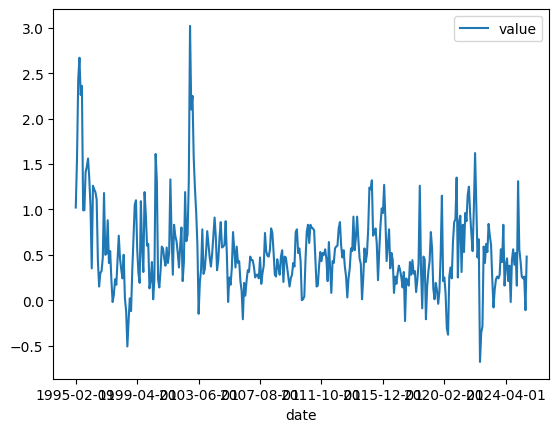

In [108]:
code = '433'
mask = df['name'] == codes[str(code)]
mask&= df['date'] > '1995-01-01'
df[mask][['date','value']].set_index('date').plot()
print(codes[str(code)])

## SQLITE


In [ ]:
import sqlite3
import pandas as pd
import matplotlib 

In [ ]:
db_path = r"D:\Fausto Stangler\Documentos\Python\FLY\data\fly.db"
raw = "tbl_statements_raw"
fetched = "tbl_statements_fetched"
stock_quote = "tbl_stock_quote"

In [ ]:
# conecta ao banco
conn = sqlite3.connect(db_path)

# lê a tabela em um DataFrame
df = pd.read_sql(f"SELECT * FROM {stock_quote}", conn)


In [ ]:
ticker = "ALPA3"

mask = df['ticker'] == ticker
df[mask]['close'].plot()

In [ ]:
# fecha a conexão se não precisar mais
conn.close()


## Ratios

### Alinhamentos

In [241]:
import pandas as pd
import numpy as np

df_data = pd.read_csv("df_data.csv")
df_data['date'] = pd.to_datetime(df_data['date'], errors='coerce')
df_data.set_index('date', inplace=True)
df_data.index = pd.DatetimeIndex(df_data.index)

df_anchor_calendar = pd.read_csv("df_anchor_calendar.csv")
df_anchor_calendar['date'] = pd.to_datetime(df_anchor_calendar['date'], errors='coerce')
df_anchor_calendar.set_index('date', inplace=True)
df_anchor_calendar.index = pd.DatetimeIndex(df_anchor_calendar.index)


In [242]:
df_data

,id,company_name,ticker,open,low,high,close,adj_close,volume,currency
date,,,,,,,,,,
2006-07-31,1217,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,3000.00,3000.00,1246.013184,0,BRL
2006-08-01,1218,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,3000.00,3000.00,1246.013184,0,BRL
2006-08-02,1219,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,10140.00,3000.00,1246.013184,0,BRL
2006-08-03,1220,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,10140.00,3000.00,1246.013184,0,BRL
2006-08-04,1221,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,3000.00,3000.00,1246.013184,0,BRL
...,...,...,...,...,...,...,...,...,...,...
2025-10-06,2075012,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,7.32,7.32,7.32,7.32,7.320000,100,BRL
2025-10-07,2075013,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,7.32,7.32,7.32,7.32,7.320000,500,BRL
2025-10-08,2075014,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,7.32,7.32,7.32,7.32,7.320000,0,BRL


In [103]:
df_anchor_calendar

,trading_days
date,
2011-01-31,20
2011-02-28,20
2011-03-31,21
2011-04-30,19
2011-05-31,22
...,...
2025-06-30,20
2025-07-31,23
2025-08-31,21


In [243]:
cols = df_data.columns
numeric_cols = df_data.select_dtypes(include='number').columns
object_cols = df_data.select_dtypes(include='object').columns

# Define agregação por tipo
agg_dict = {}

# Object (strings, etc.) → last
for col in object_cols:
    agg_dict[col] = 'last'

# Numéricas → mean
for col in numeric_cols:
    agg_dict[col] = 'mean'
agg_dict['id'] = 'count'

In [244]:
df_data2 = df_data.reset_index(drop=False)
df_data2['date'] = pd.to_datetime(df_data2['date'], errors='coerce')
df_data2 = df_data2.assign(_period=df_data2['date'].dt.to_period("M"))
df_data2

,date,id,company_name,ticker,open,low,high,close,adj_close,volume,currency,_period
0,2006-07-31,1217,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,3000.00,3000.00,1246.013184,0,BRL,2006-07
1,2006-08-01,1218,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,3000.00,3000.00,1246.013184,0,BRL,2006-08
2,2006-08-02,1219,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,10140.00,3000.00,1246.013184,0,BRL,2006-08
3,2006-08-03,1220,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,10140.00,3000.00,1246.013184,0,BRL,2006-08
4,2006-08-04,1221,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,3000.00,3000.00,1246.013184,0,BRL,2006-08
...,...,...,...,...,...,...,...,...,...,...,...,...
4765,2025-10-06,2075012,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,7.32,7.32,7.32,7.32,7.320000,100,BRL,2025-10
4766,2025-10-07,2075013,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,7.32,7.32,7.32,7.32,7.320000,500,BRL,2025-10
4767,2025-10-08,2075014,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,7.32,7.32,7.32,7.32,7.320000,0,BRL,2025-10
4768,2025-10-09,2075015,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,0.00,7.77,7.77,7.77,7.770000,0,BRL,2025-10


In [246]:
df_data2['typical_price'] = (df_data2['high'] + df_data2['low'] + df_data2['close']) / 3
df_data2['num'] = df_data2['typical_price'] * df_data2['volume'].cumsum()
df_data2['denom'] = df_data2['volume'].cumsum()
df_data2['wvap'] = (df_data2['num'] / df_data2['denom'])
df_data2

,date,id,company_name,ticker,open,low,high,close,adj_close,volume,currency,_period,typical_price,num,denom,wvap
0,2006-07-31,1217,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,3000.00,3000.00,1246.013184,0,BRL,2006-07,3000.00,0.000000e+00,0,NaN
1,2006-08-01,1218,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,3000.00,3000.00,1246.013184,0,BRL,2006-08,3000.00,0.000000e+00,0,NaN
2,2006-08-02,1219,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,10140.00,3000.00,1246.013184,0,BRL,2006-08,5380.00,0.000000e+00,0,NaN
3,2006-08-03,1220,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,10140.00,3000.00,1246.013184,0,BRL,2006-08,5380.00,0.000000e+00,0,NaN
4,2006-08-04,1221,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,3000.00,3000.00,1246.013184,0,BRL,2006-08,3000.00,0.000000e+00,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4765,2025-10-06,2075012,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,7.32,7.32,7.32,7.32,7.320000,100,BRL,2025-10,7.32,3.473590e+07,4745342,7.32
4766,2025-10-07,2075013,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,7.32,7.32,7.32,7.32,7.320000,500,BRL,2025-10,7.32,3.473956e+07,4745842,7.32
4767,2025-10-08,2075014,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,7.32,7.32,7.32,7.32,7.320000,0,BRL,2025-10,7.32,3.473956e+07,4745842,7.32
4768,2025-10-09,2075015,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,0.00,7.77,7.77,7.77,7.770000,0,BRL,2025-10,7.77,3.687519e+07,4745842,7.77


In [231]:
group = df_data2.groupby('_period')

monthly = group.agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'adj_close': 'last',
    'volume': 'sum',
    'ticker': 'last',
    'company_name': 'last',
    'id': 'count',
    'currency': 'last',
})


numer = (df_data2['typical_price'] * df_data2['volume']).groupby(df_data2['_period']).sum()
denom = df_data2['volume'].groupby(df_data2['_period']).sum()
monthly['vwap'] = np.where(denom > 0, numer / denom, np.nan)
monthly['desviation_vwap %'] = (monthly['typical_price'] - monthly['vwap']) / monthly['typical_price'] * 100

stats = group['vwap'].agg(['mean', 'std'])
monthly = monthly.join(stats, on='_period')




monthly

KeyError: 'typical_price'

ValueError: could not convert string to float: 'AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA'

In [145]:
#. agrega por mês usando PeriodIndex para evitar depender de datas de fim-de-mês
df_data.index = pd.DatetimeIndex(df_data.index)

monthly_data = (
    df_data
    .assign(_period=df_data.index.to_period('M'))
    .groupby('_period')
    .agg(agg_dict)
)
monthly_data

,id,company_name,ticker,open,low,high,close,adj_close,volume,currency,_period
date,,,,,,,,,,,
2006-07-31,1217,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,3000.00,3000.00,1246.013184,0,BRL,2006-07
2006-08-01,1218,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,3000.00,3000.00,1246.013184,0,BRL,2006-08
2006-08-02,1219,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,10140.00,3000.00,1246.013184,0,BRL,2006-08
2006-08-03,1220,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,10140.00,3000.00,1246.013184,0,BRL,2006-08
2006-08-04,1221,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,3000.00,3000.00,1246.013184,0,BRL,2006-08
...,...,...,...,...,...,...,...,...,...,...,...
2025-10-06,2075012,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,7.32,7.32,7.32,7.32,7.320000,100,BRL,2025-10
2025-10-07,2075013,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,7.32,7.32,7.32,7.32,7.320000,500,BRL,2025-10
2025-10-08,2075014,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,7.32,7.32,7.32,7.32,7.320000,0,BRL,2025-10


In [113]:
cols = df_anchor_calendar.columns
numeric_cols = df_anchor_calendar.select_dtypes(include='number').columns
object_cols = df_anchor_calendar.select_dtypes(include='object').columns

# Define agregação por tipo
agg_dict = {}

# Object (strings, etc.) → last
for col in object_cols:
    agg_dict[col] = 'first'

# Numéricas → mean
for col in numeric_cols:
    agg_dict[col] = 'sum'

In [116]:
monthly_data = (
    df_anchor_calendar
    .assign(_period=df_anchor_calendar.index.to_period('M'))
    .groupby('_period')
    .agg(agg_dict)
)
monthly_data[cols]

,trading_days
_period,
2011-01,20
2011-02,20
2011-03,21
2011-04,19
2011-05,22
...,...
2025-06,20
2025-07,23
2025-08,21


In [ ]:
# Executa
monthly = df_data.groupby(pd.Grouper(freq='B')).agg(agg_dict)
dropped = monthly[monthly[numeric_cols].isna().any(axis=1)]
monthly[cols]

In [73]:
import pandas as pd

# df_anchor_calendar: calendário MENSAL (baixa granularidade)
anchor_index = pd.to_datetime(['2024-01-31', '2024-02-29', '2024-03-31'])
df_anchor_calendar = pd.DataFrame({'month': ['Jan', 'Fev', 'Mar']}, index=anchor_index)

# df_data: cotações DIÁRIAS (alta granularidade)
data_index = pd.to_datetime([
    '2024-01-15', '2024-01-16', '2024-01-30', '2024-01-31',
    '2024-02-15', '2024-02-29',
    '2024-03-31', '2024-04-01'  # fora do range!
])
df_data = pd.DataFrame({
    'close': [100, 101, 102, 103, 104, 105, 106, 107]
}, index=data_index)

print("df_data (alta granularidade):")
print(df_data)

df_data (alta granularidade):
            close
2024-01-15    100
2024-01-16    101
2024-01-30    102
2024-01-31    103
2024-02-15    104
2024-02-29    105
2024-03-31    106
2024-04-01    107


In [74]:
# REINDEX para o calendário mensal
df_aligned = df_data.reindex(df_anchor_calendar.index, method='ffill')
print("\ndf_aligned (após reindex):")
print(df_aligned)


df_aligned (após reindex):
            close
2024-01-31    103
2024-02-29    105
2024-03-31    106


In [85]:
# 1. Agrupe df_data por mês (mantendo alta granularidade)
monthly_raw = df_data.groupby(df_data.index.to_period('M')).agg({'close': 'mean'})

# 2. Reindex para o calendário final
monthly = monthly_raw.reindex(df_anchor_calendar.index.to_period('M')).to_timestamp(how='end')
monthly

,close
2024-01-31 23:59:59.999999999,101.5
2024-02-29 23:59:59.999999999,104.5
2024-03-31 23:59:59.999999999,106.0


### RAW code

In [1]:
import sqlite3
import pandas as pd

In [2]:
db_path  = r"D:\Fausto Stangler\Documentos\Python\FLY\data\fly.db"
conn = sqlite3.connect(db_path)


In [3]:
df = pd.read_sql_query("SELECT * FROM tbl_statements_ratio", conn)
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()



In [4]:
mask = df['ticker'] == 'AFLT3'
mask&= df['account'].str.startswith('99.3.close')

cols = ['value']

In [7]:
df['company_name'].unique()

array(['ALFA HOLDINGS SA', 'AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA',
       'AGROGALAXY PARTICIPACOES SA'], dtype=object)

<Axes: xlabel='date'>

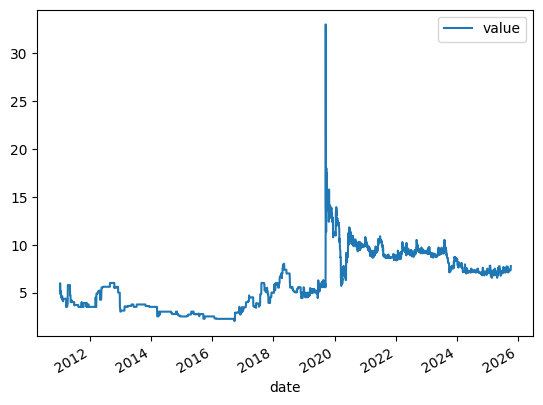

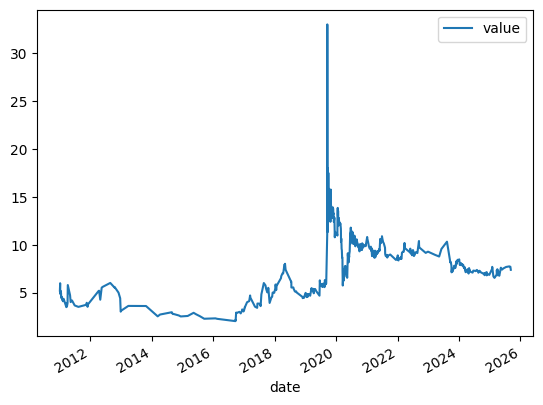

In [62]:
df[mask][cols].plot()
df[mask][cols].drop_duplicates().plot()

### Cache

In [1]:
from pathlib import Path
import pandas as pd
import hashlib, json, sqlite3
import pyarrow as pa
import pyarrow.parquet as pq
import inspect


In [2]:
def set_df_hash(df, row_hash="row_hash"):
    df = df.sort_index()
    df['date'] = df.index.strftime('%Y-%m-%d %H:%M:%S.%f')
    df[row_hash] = df.astype(str).agg('|'.join, axis=1).apply(lambda r: hashlib.sha256(r.encode("utf-8")).hexdigest())
    df = df.drop(columns=['date'])
    hash_df = hashlib.sha256("".join(df.sort_index()[row_hash]).encode("utf-8")).hexdigest()
    return df, hash_df


In [3]:
def hash_diff(df_old, df_new, hash_col='row_hash'):
    if df_old.columns.tolist() != df_new.columns.tolist():
        return pd.DataFrame()
    hash_diff = df_old[[hash_col]].join(df_new[[hash_col]], lsuffix='_old', rsuffix='_new')
    hash_diff['changed'] = hash_diff[f'{hash_col}_old'] != hash_diff[f'{hash_col}_new']
    indices = hash_diff[hash_diff['changed']].index
    
    if len(indices) == 0:
        return pd.DataFrame()
    
    old = df_old.loc[indices]
    new = df_new.loc[indices]
    cols = [c for c in df_old.columns if c != hash_col]
    
    diffs = []
    for idx in indices:
        o = old.loc[idx, cols]
        n = new.loc[idx, cols]
        chg = o[o != n].index
        for col in chg:
            diffs.append({'data': idx, 'column': col, 'old': o[col], 'new': n[col]})
    
    return pd.DataFrame(diffs).sort_values(['data', 'column']).reset_index(drop=True)


In [4]:
BASE = Path(".")
CACHE_DIR = BASE / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
SQLITE = BASE / "cache.db"

logical_name = "statements_ratio"
version = 1 # Increment this when the calculation logic (e.g., the ratio formula) changes


###### DataFrames

In [5]:
indicators = pd.read_csv('indicators.csv')
indicators["date"] = pd.to_datetime(indicators["date"], errors="coerce")
indicators = indicators.set_index("date").sort_index()
i = indicators.sort_index().index

quotes = pd.read_csv("quotes.csv")
quotes["date"] = pd.to_datetime(quotes["date"], errors="coerce")
quotes = quotes.set_index("date").sort_index()
q = quotes.sort_index()

statements = pd.read_csv("statements.csv")
s = statements.sort_index().copy()

key_columns = ["company_name", "quarter", "account"]
# sep = " - "
s["account_description"] = s["account"] + " - " + s["description"] + " - " + s["grupo"] + " - " + s["quadro"]

context_columns = ["nsd", "company_name", "version"]
meta = (
    s[["quarter"] + context_columns]
    .drop_duplicates(subset=["quarter"], keep="last")
    .set_index("quarter")
)

s = s.sort_values(key_columns)
s = s.drop_duplicates(subset=key_columns, keep="last")
s = s.pivot_table(index=["quarter"],
                        columns="account_description",  # use "description" se preferir nomes ou "account" se preferir contas
                        values="value",
                        aggfunc="last").sort_index()
s.columns.name = None

s = meta.join(s, how="right")

if q is not None:
    # reset_multiindex
    s = s.copy()
    # s.index = s.index.set_names(["quarter", "nsd", "company_name", "version"])
    s = s.reset_index()

    # create date index
    s["quarter"] = pd.to_datetime(s["quarter"])
    s = (
        s.rename(columns={"quarter": "date"})
        .set_index("date")
        .sort_index()
    )

    # reindex ffill bfill
    s = s.reindex(q.index, method="ffill")
    if s.iloc[0].isna().any():
        s = s.bfill()

    # recreate multiindex
    s = s.set_index(context_columns, append=True).sort_index()
    s = s.reset_index(level=context_columns)
    quotes.to_csv('q.csv', index=True)
    s.to_csv('s.csv', index=True)

i_hash = hashlib.sha256(pd.util.hash_pandas_object(i, index=True).sum()).hexdigest()
q_hash = hashlib.sha256(pd.util.hash_pandas_object(q, index=True).sum()).hexdigest()
s_hash = hashlib.sha256(pd.util.hash_pandas_object(s, index=True).sum()).hexdigest()
i_hash, q_hash, s_hash

('e3d5ad7a6515257a7cbf83dbb205d7e8c729ba0dc31b913dde44d4783968020c',
 'c9a9f860994b8faddc8efe13e3949812744b744a3a3de8f7e1def1c6c76daf7c',
 '2a898a56d4f0f1bdaa647b809aa9050f4e87a069c0346c7dadf993eaac64aac5')

In [6]:
q0, q0_hash = set_df_hash(q)
s0, s0_hash = set_df_hash(s)

s0_copy = s.copy()
s0_copy.loc['2006-11-21 00:00:00', '00.01.02 - Ações PN Circulação - Dados da Empresa - Composição do Capital'] = 1000

s1, s1_hash = set_df_hash(s0_copy)

q0_hash, s0_hash, s1_hash

('545a3494993511d40ff17eed891a6c30074808da85f314107e2402ed4995288c',
 '5be49b30000ed3a1c52f8727db5bb238203a2d4c585e0fbe5064f7c5b38d78a8',
 'c9640d53c8903253efcfaf150377867b0a780c8b4b506125678c6dd46cf0c095')

In [7]:
diffs = None
if s0_hash != s1_hash:
    diffs = hash_diff(s0, s1)
diffs

,data,column,old,new
0,2006-11-21,00.01.02 - Ações PN Circulação - Dados da Empr...,0.0,1000.0


In [8]:
def calculate_ratios(q, s):
    # CÓDIGO CRÍTICO DE CÁLCULO
    s = s.reindex(q.index, method='ffill') 
    # s_col = s.columns[[c.startswith("03.01") for c in s.columns.tolist()]]
    col_03_01 = '03.01 - Receita de Venda de Bens e/ou Serviços - DFs Individuais - Demonstração do Resultado'
    col_03_11 = '03.11 - Lucro do Período - DFs Individuais - Demonstração do Resultado'

    ratio_df = pd.DataFrame(index=q.index)

    ratio_df['PriceToRevenue'] = q['adj_close'] / s[col_03_01]
    ratio_df['PriceToEarnings'] = q['adj_close'] / s[col_03_11]
    ratio_df['ROE'] = s[col_03_11]  / s[col_03_01] * 100
    return ratio_df

# 1. Obter o código-fonte (a string) da função
calculate_ratios_str = inspect.getsource(calculate_ratios)
ratios_method_hash = hashlib.sha256(calculate_ratios_str.encode()).hexdigest()
ratios_method_hash

'a193e99cd4b7d3567aa9130157942651ecc76dc713216f4e2c56a131f4bbaeb1'

In [9]:
app_hash = hashlib.sha256(f"{logical_name}|{version}".encode()).hexdigest()
cache_key = hashlib.sha256( f"{app_hash}{q_hash}{s_hash}{i_hash}{ratios_method_hash}".encode()).hexdigest()
cache_key

'16fde69a498030786592e73b75aad29783d2decb3a6c07d98120332563fedd87'

In [10]:
import sqlite3
from datetime import datetime

DB_PATH = 'cache/fly_cache.db'

def init_cache_table():
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS cache (
            cache_key TEXT PRIMARY KEY,
            file_path TEXT NOT NULL,
            size_bytes INTEGER NOT NULL,
            created_at TEXT NOT NULL,
            accessed_at TEXT NOT NULL,
            access_count INTEGER DEFAULT 0,
            code_hash TEXT NOT NULL  -- NOVO: hash do método
        )
    ''')
    
    # Adicionar coluna se não existir (para compatibilidade)
    try:
        cursor.execute("ALTER TABLE cache ADD COLUMN code_hash TEXT")
    except sqlite3.OperationalError:
        pass  # Já existe
    
    conn.commit()
    conn.close()



In [11]:
MAX_CACHE_SIZE_BYTES = 1_000_000_000
MAX_AGE_DAYS = 30  # Expira se não acessado em 30 dias

def evict_cache_if_needed(conn):
    cursor = conn.cursor()
    
    # 1. Expiração por tempo: Deletar velhos
    cutoff_time = (datetime.now() - pd.Timedelta(days=MAX_AGE_DAYS)).isoformat()
    cursor.execute("SELECT file_path FROM cache WHERE accessed_at < ?", (cutoff_time,))
    for (path,) in cursor.fetchall():
        if os.path.exists(path):
            os.remove(path)
    cursor.execute("DELETE FROM cache WHERE accessed_at < ?", (cutoff_time,))
    conn.commit()
    
    # 2. Expiração por tamanho: Enquanto total > MAX, deletar o menos acessado/mais antigo
    cursor.execute("SELECT SUM(size_bytes) FROM cache")
    total_size = cursor.fetchone()[0] or 0
    
    while total_size > MAX_CACHE_SIZE_BYTES:
        # Encontrar o a evictar: Ordenar por access_count ASC, created_at ASC (LFU + LRU simples)
        cursor.execute("""
            SELECT cache_key, file_path, size_bytes 
            FROM cache 
            ORDER BY access_count ASC, created_at ASC 
            LIMIT 1
        """)
        row = cursor.fetchone()
        if not row:
            break
        
        cache_key, path, size = row
        if os.path.exists(path):
            os.remove(path)
        cursor.execute("DELETE FROM cache WHERE cache_key = ?", (cache_key,))
        conn.commit()
        
        total_size -= size  # Atualizar total (aproximado; para precisão, requery)

In [12]:
def invalidate_old_caches(code_hash=ratios_method_hash, conn=None):
    """
    Deleta todos os caches cujo code_hash != current_code_hash
    """
    evict_cache_if_needed(conn)  # Função abaixo

    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    
    # Pegar todos com code_hash diferente
    cursor.execute("""
        SELECT file_path, code_hash 
        FROM cache 
        WHERE code_hash != ?
    """, (code_hash,))
    
    deleted_count = 0
    for file_path, old_hash in cursor.fetchall():
        if os.path.exists(file_path):
            os.remove(file_path)
            print(f"[INVALIDATED] {file_path} (método antigo) {old_hash}")
        deleted_count += 1
    
    # Deletar do DB
    cursor.execute("DELETE FROM cache WHERE code_hash != ?", (code_hash,))
    conn.commit()
    conn.close()
    
    if deleted_count > 0:
        print(f"Invalidated {deleted_count} cache(s) due to method change.")
    else:
        print("All caches up to date.")

In [13]:
import os
import pandas as pd

CACHE_DIR = 'cache/'  # Pasta para .parquets
os.makedirs(CACHE_DIR, exist_ok=True)

def get_or_compute_ratios(q, s, i=None, code_hash=ratios_method_hash):  # Assuma 'i' se for outro input
    init_cache_table()  # Rode uma vez ou sempre no startup
    # Calcular hashs (se não pré-computados)
    q_hash = hashlib.sha256(pd.util.hash_pandas_object(q, index=True).sum()).hexdigest()
    s_hash = hashlib.sha256(pd.util.hash_pandas_object(s, index=True).sum()).hexdigest()
    i_hash = hashlib.sha256(pd.util.hash_pandas_object(i, index=True).sum()).hexdigest() if i is not None else ''
    ratios_method_hash = hashlib.sha256(inspect.getsource(calculate_ratios).encode()).hexdigest()
    
    app_hash = hashlib.sha256(f"{logical_name}|{version}".encode()).hexdigest()
    cache_key = hashlib.sha256(f"{app_hash}{q_hash}{s_hash}{i_hash}{ratios_method_hash}".encode()).hexdigest()
    
    file_path = os.path.join(CACHE_DIR, f"{cache_key}")
    
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    
    try:# Verificar se existe
        cursor.execute("SELECT file_path, size_bytes FROM cache WHERE cache_key = ?", (cache_key,))
        row = cursor.fetchone()
        
        if row:
            db_file_path = row[0]
            if os.path.exists(row[0]):
                try:
                    print(f"Cache HIT: {cache_key}")
                    df = pd.read_parquet(file_path)
                    
                    # Atualizar accessed_at e access_count
                    cursor.execute("""
                        UPDATE cache 
                        SET accessed_at = ?, access_count = access_count + 1 
                        WHERE cache_key = ?
                    """, (datetime.now().isoformat(), cache_key))
                    conn.commit()
                    return df
                except Exception as e:
                    if os.path.exists(db_file_path):
                        os.remove(db_file_path)
                    cursor.execute("DELETE FROM cache WHERE cache_key = ?", (cache_key,))
                    conn.commit()
    
        print(f"Cache MISS: {cache_key}")
        
        # Eviction antes de adicionar novo (para controlar tamanho)
        invalidate_old_caches(code_hash=ratios_method_hash, conn=conn)

        # Computar
        df_ratios = calculate_ratios(q, s)  # Sua função (adicione 'i' se necessário)
        
        # Salvar .parquet
        df_ratios.to_parquet(file_path, compression='zstd')  # Compacto
        
        # Calcular tamanho
        size_bytes = os.path.getsize(file_path)
        
        now_iso = datetime.now().isoformat()
        
        # Inserir no DB
        cursor.execute('''
                INSERT INTO cache 
                (cache_key, file_path, size_bytes, created_at, accessed_at, access_count, code_hash)
                VALUES (?, ?, ?, ?, ?, ?, ?)
            ''', (cache_key, file_path, size_bytes, now_iso, now_iso, 1, code_hash))

        conn.commit()

    finally:
        conn.close()  # SEMPRE fecha    conn.close()

    return df_ratios

In [49]:
df_ratios = get_or_compute_ratios(q, s, i)
df_ratios = get_or_compute_ratios(q, s0, q)
df_ratios = get_or_compute_ratios(q, s0, s)
df_ratios = get_or_compute_ratios(q, s0, s1)
df_ratios = get_or_compute_ratios(q, s0, q)
df_ratios = get_or_compute_ratios(q, s0, i)

df_ratios

Cache MISS: 16fde69a498030786592e73b75aad29783d2decb3a6c07d98120332563fedd87


OperationalError: database is locked

,nsd,company_name,version,00.01.01 - Ações ON Circulação - Dados da Empresa - Composição do Capital,00.01.02 - Ações PN Circulação - Dados da Empresa - Composição do Capital,00.02.01 - Ações ON Tesouraria - Dados da Empresa - Composição do Capital,00.02.02 - Ações PN Tesouraria - Dados da Empresa - Composição do Capital,01 - Ativo Total - DFs Consolidadas - Balanço Patrimonial Ativo,01.01 - Ativo Circulante de Curto Prazo - DFs Consolidadas - Balanço Patrimonial Ativo,01.01.01 - Caixa e Equivalentes de Caixa de Curto Prazo - DFs Consolidadas - Balanço Patrimonial Ativo,...,25.04 - Preço/Fluxo de Caixa por Ação (P/FC) Total,25.05 - Preço/Fluxo de Caixa por Ação (P/FC) ON,25.06 - Preço/Fluxo de Caixa por Ação (P/FC) PN,27.05 - Taxa de Retenção de Lucros por Ação Total,28.05 - Capitalização de Mercado por Patrimônio Líquido,29.01 - Fluxo de Caixa Operacional por Ação Total,29.02 - Fluxo de Caixa Operacional por Ação ON,29.03 - Fluxo de Caixa Operacional por Ação PN,30.01 - Valor Econômico Adicionado (EVA),30.02 - Valor de Mercado Adicionado (MVA)
date,,,,,,,,,,,,,,,,,,,,,
2021-07-31,108019,AGROGALAXY PARTICIPACOES SA,1,145370444.0,0.0,3395679.0,0.0,4.514524e+09,3.357589e+09,2.696020e+08,...,-10.292651,-20.585303,0.0,1.000000,-11.200992,-13.500787,-13.500787,0.0,0.0,2.059937e+10
2021-08-31,108019,AGROGALAXY PARTICIPACOES SA,1,145370444.0,0.0,3395679.0,0.0,4.514524e+09,3.357589e+09,2.696020e+08,...,-8.287439,-16.574878,0.0,1.000000,-9.018817,-13.500787,-13.500787,0.0,0.0,1.691513e+10
2021-09-30,109827,AGROGALAXY PARTICIPACOES SA,1,170824989.0,0.0,3395679.0,0.0,5.967491e+09,4.636451e+09,5.413900e+08,...,-9.705478,-19.410955,0.0,1.000000,-12.589516,-13.384479,-13.384479,0.0,0.0,2.304287e+10
2021-10-31,109827,AGROGALAXY PARTICIPACOES SA,1,170824989.0,0.0,3395679.0,0.0,5.967491e+09,4.636451e+09,5.413900e+08,...,-8.004165,-16.008329,0.0,1.000000,-10.382648,-13.384479,-13.384479,0.0,0.0,1.930083e+10
2021-11-30,109827,AGROGALAXY PARTICIPACOES SA,1,170824989.0,0.0,3395679.0,0.0,5.967491e+09,4.636451e+09,5.413900e+08,...,-10.242134,-20.484268,0.0,1.000000,-13.285643,-13.384479,-13.384479,0.0,0.0,2.422325e+10
2021-12-31,113081,AGROGALAXY PARTICIPACOES SA,1,170824989.0,0.0,3395679.0,0.0,6.774910e+09,5.405111e+09,6.435630e+08,...,-11.975131,-23.950262,0.0,0.761774,-16.564341,-13.612766,-13.612766,0.0,0.0,2.841482e+10
2022-01-31,113081,AGROGALAXY PARTICIPACOES SA,1,170824989.0,0.0,3395679.0,0.0,6.774910e+09,5.405111e+09,6.435630e+08,...,-12.491397,-24.982793,0.0,0.761774,-17.278454,-13.612766,-13.612766,0.0,0.0,2.957008e+10
2022-02-28,113081,AGROGALAXY PARTICIPACOES SA,1,170824989.0,0.0,3395679.0,0.0,6.774910e+09,5.405111e+09,6.435630e+08,...,-12.345495,-24.690991,0.0,0.761774,-17.076640,-13.612766,-13.612766,0.0,0.0,2.924359e+10
2022-03-31,115302,AGROGALAXY PARTICIPACOES SA,1,170824989.0,0.0,3395679.0,0.0,8.975134e+09,7.399053e+09,5.103120e+08,...,-10.453395,-20.906789,0.0,1.000000,-14.330059,-16.149407,-16.149407,0.0,0.0,3.143435e+10


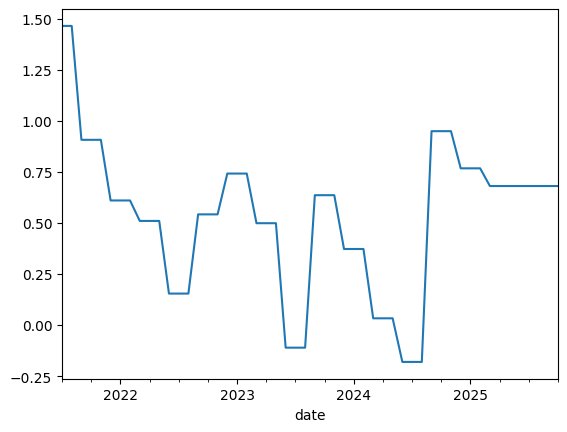

In [24]:
df = pd.read_parquet("cache/40fc92b74f6faf651593ad78faef859101120d5b0aa927da93c52947acbf962c.parquet")
# df['30.02 - Valor de Mercado Adicionado (MVA)'].plot()
df['18.03 - Valor Adicionado Bruto por Valor Agregado'].plot()
df

In [420]:
r = calculate_ratios(q, s)
r

,PriceToRevenue,PriceToEarnings,ROE
date,,,
2006-07-31,3.921363e-05,0.000065,59.880409
2006-08-01,3.921363e-05,0.000065,59.880409
2006-08-02,3.921363e-05,0.000065,59.880409
2006-08-03,3.921363e-05,0.000065,59.880409
2006-08-04,3.921363e-05,0.000065,59.880409
...,...,...,...
2025-10-06,6.780289e-07,0.000001,45.868840
2025-10-07,6.780289e-07,0.000001,45.868840
2025-10-08,6.780289e-07,0.000001,45.868840


In [110]:
base = s.sort_index().copy()
base['date'] = base.index.map(lambda x: x.isoformat())
base['row_hash'] = base[sorted(base.columns.tolist())].astype(str).agg('|'.join, axis=1).apply(lambda x: hashlib.sha256(x.encode("utf-8")).hexdigest())
base = base.drop(columns=['date'])
hash_s = hashlib.sha256("".join(base.sort_index(ascending=True)["row_hash"]).encode("utf-8")).hexdigest()
hash_s

'b8e4730f622ac8f84256d02aa5af9ae3db21d734ee8b8efce6ff72fbb40e45a8'

In [167]:
snapshot_antigo = base[["row_hash"]].copy()
s1 = s.sort_index().copy()
s1.loc['2006-07-31 00:00:00', '00.01.02 - Ações PN Circulação - Dados da Empresa - Composição do Capital'] = 999
s1['date'] = s1.index.map(lambda x: x.isoformat())
s1['row_hash'] = s1[sorted(s1.columns.tolist())].astype(str).agg('|'.join, axis=1).apply(lambda x: hashlib.sha256(x.encode("utf-8")).hexdigest())
s1 = s1.drop(columns=['date'])
hash_s1 = hashlib.sha256("".join(s1.sort_index(ascending=True)["row_hash"]).encode("utf-8")).hexdigest()
hash_s1


'3f56a48bfa2ee5535bfb7ed266e23b74551cf7d28bb2f8a440e886db16c648c7'

In [168]:
diff = hash_diff(base, s1)
diff

,data,column,old,new
0,2006-07-31,00.01.02 - Ações PN Circulação - Dados da Empr...,0.0,999.0


#### Code

In [ ]:
def hash_dataframe(df):
    h = hashlib.sha256()
    h.update(pd.util.hash_pandas_object(df, index=True).values)
    return h.hexdigest()


In [289]:
cache_dir=Path("cache")
tolerance="1D"

In [291]:
hash_dataframe(statements)

'fe40bd2bf4673fbddbce17445ef3b311aee136a060232cc19ed577c2fe2ca859'

In [302]:
key = hashlib.sha256(
    (hash_dataframe(quotes) + hash_dataframe(statements) + tolerance).encode()
).hexdigest()
path = cache_dir / f"{key}.parquet"
if path.exists():
    print("→ Lendo do cache:", path)
merged = pd.merge_asof(
    quotes.sort_index(), statements.sort_index(),
    left_index=True, right_index=True,
    direction="backward", tolerance=pd.to_timedelta(tolerance)
    )
merged = pd.merge_asof(
    quotes.sort_index(), statements.sort_index(),
    left_index=True, right_index=True,
    direction="backward", tolerance=None
)
merged.to_csv("merged.csv", index=False)


In [303]:
df = statements.reindex(quotes.sort_index().index, method="ffill")
df

ValueError: cannot reindex on an axis with duplicate labels

In [ ]:
cache_dir.mkdir(exist_ok=True)
key = hashlib.sha256(
    (hash_dataframe(quotes) + hash_dataframe(statements) + tolerance).encode()
).hexdigest()
path = cache_dir / f"{key}.parquet"
if path.exists():
    print("→ Lendo do cache:", path)
    return pq.read_table(path).to_pandas()
print("→ Calculando...")
merged = pd.merge_asof(
    left_df.sort_index(), right_df.sort_index(),
    left_index=True, right_index=True,
    direction="backward", tolerance=pd.to_timedelta(tolerance)
)
merged["ratio"] = merged.iloc[:,0] / merged.iloc[:,1]
pq.write_table(pa.Table.from_pandas(merged), path, compression="zstd")
merged


In [ ]:
# Função de hash estável

# Função que calcula e salva em cache
def compute_with_cache(left_df, right_df, cache_dir=Path("cache"), tolerance="1D"):
    cache_dir.mkdir(exist_ok=True)
    key = hashlib.sha256(
        (hash_dataframe(left_df) + hash_dataframe(right_df) + tolerance).encode()
    ).hexdigest()
    path = cache_dir / f"{key}.parquet"
    if path.exists():
        print("→ Lendo do cache:", path)
        return pq.read_table(path).to_pandas()
    print("→ Calculando...")
    merged = pd.merge_asof(
        left_df.sort_index(), right_df.sort_index(),
        left_index=True, right_index=True,
        direction="backward", tolerance=pd.to_timedelta(tolerance)
    )
    merged["ratio"] = merged.iloc[:,0] / merged.iloc[:,1]
    pq.write_table(pa.Table.from_pandas(merged), path, compression="zstd")
    return merged

# Executar duas vezes
df1 = compute_with_cache(quotes, indicators)
df2 = compute_with_cache(quotes, indicators)


,id,company_name,ticker,open,low,high,close,adj_close,volume,currency
date,,,,,,,,,,
2006-07-31,1217,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,3000.00,3000.00,1246.013184,0,BRL
2006-08-01,1218,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,3000.00,3000.00,1246.013184,0,BRL
2006-08-02,1219,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,10140.00,3000.00,1246.013184,0,BRL
2006-08-03,1220,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,10140.00,3000.00,1246.013184,0,BRL
2006-08-04,1221,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,3000.00,3000.00,3000.00,3000.00,1246.013184,0,BRL
...,...,...,...,...,...,...,...,...,...,...
2025-10-06,2075012,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,7.32,7.32,7.32,7.32,7.320000,100,BRL
2025-10-07,2075013,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,7.32,7.32,7.32,7.32,7.320000,500,BRL
2025-10-08,2075014,AFLUENTE TRANSMISSAO DE ENERGIA ELETRICA SA,AFLT3,7.32,7.32,7.32,7.32,7.320000,0,BRL


### Métodos FLY

In [77]:
import datetime
import pandas as pd

In [156]:
raw_quotes = pd.read_csv("quotes_ALPA3.csv")
raw_statements = pd.read_csv("statements_con.csv")
raw_indicators = pd.read_csv("indicators_11.csv")

In [ ]:
def _treat_quotes(q, cutoff=None):
    if not cutoff:
        cutoff = datetime.datetime(year=2010, month=12, day=31)

    q["date"] = pd.to_datetime(q["date"])
    q = q.sort_values("date").drop_duplicates(subset=["date"]).set_index("date")
    if cutoff:
        q = q[q.index >= cutoff]
    return q

In [ ]:
def _treat_statements(s, c):
    if c.empty:
        return pd.DataFrame()

    key_columns = ["company_name", "quarter", "grupo", "quadro", "account"]
    s["account_description"] = s["account"].str.cat(s["description"], sep=" - ")
    s["quarter"] = pd.to_datetime(s["quarter"])
    s = s.sort_values(key_columns)
    s = s.drop_duplicates(subset=key_columns, keep="last")
    statements_wide = s.pivot_table(index="quarter",
                            columns="account_description",  # use "description" se preferir nomes ou "account" se preferir contas
                            values="value",
                            aggfunc="last").sort_index()
    statements_wide.columns.name = None

    s = statements_wide.sort_index().reindex(c.index, method="ffill")
    if s.iloc[0].isna().any():
        s = s.bfill()

    return s


In [142]:
def _indicators(i, c):
    if c.empty:
        return pd.DataFrame()

    indicators_wide = indicators.copy()
    indicators_wide["date"] = pd.to_datetime(indicators_wide["date"])
    indicators_wide = indicators_wide.sort_values("date").drop_duplicates(subset=["date"]).set_index("date")

    i = indicators_wide.sort_index().reindex(c.index, method="ffill")
    if i.iloc[0].isna().any():
        i = i.bfill()

    return i

'2010-12-31'

In [165]:
cutoff = datetime.datetime(year=2024, month=12, day=31)
cutoff = raw_statements['quarter'].min()

q = _quotes(raw_quotes, cutoff)
s = _statements(raw_statements, q)
i = _indicators(raw_indicators, q)


In [168]:
s

,00.01.01 - Ações ON Circulação,00.01.02 - Ações PN Circulação,00.02.01 - Ações ON Tesouraria,00.02.02 - Ações PN Tesouraria,01 - Ativo Total,01.01 - Ativo Circulante de Curto Prazo,01.01.01 - Caixa e Equivalentes de Caixa de Curto Prazo,01.01.02 - Aplicações Financeiras de Curto Prazo,01.01.02.01 - Aplicações a Valor Justo de Curto Prazo,01.01.02.02 - Aplicações ao Custo Amortizado de Curto Prazo,...,07.08.03.01 - Juros,07.08.03.02 - Aluguéis,07.08.03.03 - Outras,07.08.04 - Remuneração de Capitais Próprios,07.08.04.01 - Juros sobre o Capital Próprio,07.08.04.02 - Dividendos,07.08.04.03 - Lucros Retidos / Prejuízo do Período,07.08.04.04 - Part. Não Controladores nos Lucros Retidos,07.08.05 - Outros,07.08.05.09 - Outros
date,,,,,,,,,,,,,,,,,,,,,
2011-01-03,181524000.0,171932000.0,0.0,5093000.0,2.246603e+09,1.473791e+09,482488000.0,172177000.0,0.0,172177000.0,...,23973000.0,23337000.0,15533000.0,310452000.0,63412000.0,0.0,242929000.0,4111000.0,0.0,0.0
2011-01-04,181524000.0,171932000.0,0.0,5093000.0,2.246603e+09,1.473791e+09,482488000.0,172177000.0,0.0,172177000.0,...,23973000.0,23337000.0,15533000.0,310452000.0,63412000.0,0.0,242929000.0,4111000.0,0.0,0.0
2011-01-05,181524000.0,171932000.0,0.0,5093000.0,2.246603e+09,1.473791e+09,482488000.0,172177000.0,0.0,172177000.0,...,23973000.0,23337000.0,15533000.0,310452000.0,63412000.0,0.0,242929000.0,4111000.0,0.0,0.0
2011-01-06,181524000.0,171932000.0,0.0,5093000.0,2.246603e+09,1.473791e+09,482488000.0,172177000.0,0.0,172177000.0,...,23973000.0,23337000.0,15533000.0,310452000.0,63412000.0,0.0,242929000.0,4111000.0,0.0,0.0
2011-01-07,181524000.0,171932000.0,0.0,5093000.0,2.246603e+09,1.473791e+09,482488000.0,172177000.0,0.0,172177000.0,...,23973000.0,23337000.0,15533000.0,310452000.0,63412000.0,0.0,242929000.0,4111000.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-06,339510689.0,343551533.0,32.0,5251413.0,6.194674e+09,3.031060e+09,864577000.0,0.0,0.0,0.0,...,58260000.0,6246000.0,6865000.0,86956000.0,0.0,0.0,87892000.0,-936000.0,0.0,0.0
2025-10-07,339510689.0,343551533.0,32.0,5251413.0,6.194674e+09,3.031060e+09,864577000.0,0.0,0.0,0.0,...,58260000.0,6246000.0,6865000.0,86956000.0,0.0,0.0,87892000.0,-936000.0,0.0,0.0
2025-10-08,339510689.0,343551533.0,32.0,5251413.0,6.194674e+09,3.031060e+09,864577000.0,0.0,0.0,0.0,...,58260000.0,6246000.0,6865000.0,86956000.0,0.0,0.0,87892000.0,-936000.0,0.0,0.0
